# Frozen ResNet18 embeddings for EuroSAT

This notebook implements Stage 3 of the Calibrated EuroSAT project. It uses an
ImageNet-pretrained ResNet18 as a fixed 512-dimensional feature extractor and a
standardized multinomial logistic-regression classifier. Model selection uses
the fixed validation partition; the test partition is evaluated once only after
the representation and regularization strength are frozen.

**Protocol:** fixed stratified 70/15/15 split, seed 42, split checksum
`f97c4ec9a27435a932662d5a8b707255`.

In [1]:
import platform
import random

import numpy as np
import sklearn
import torch
import torchvision

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", DEVICE)


Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
Selected device: cuda


## 1. Runtime and reproducibility controls

In [2]:
from pathlib import Path
from torchvision.datasets import EuroSAT

DATA_BASE = Path("/kaggle/working/data")

eurosat = EuroSAT(
    root=DATA_BASE,
    download=True
)

DATA_ROOT = DATA_BASE / "eurosat" / "2750"

print("Images:", len(eurosat))
print("Classes:", eurosat.classes)
print("Class mapping:", eurosat.class_to_idx)
print("Image directory:", DATA_ROOT)

100%|██████████| 94.3M/94.3M [00:00<00:00, 108MB/s]


Images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Class mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
Image directory: /kaggle/working/data/eurosat/2750


## 2. Dataset acquisition

Torchvision downloads the official EuroSAT RGB archive into Kaggle's working
directory. The raw images are not committed to Git.

In [3]:
import pandas as pd

SPLIT_URL = (
    "https://raw.githubusercontent.com/"
    "Cricdatahater/calibrated-eurosat/main/data/splits"
)

splits = {
    "train": pd.read_csv(f"{SPLIT_URL}/train.csv"),
    "validation": pd.read_csv(f"{SPLIT_URL}/validation.csv"),
    "test": pd.read_csv(f"{SPLIT_URL}/test.csv"),
}

for name, frame in splits.items():
    print(name, frame.shape)
    display(frame.head(2))

train (18900, 5)


,dataset_index,relative_path,class_name,class_index,split
0,20034,eurosat/2750/Residential/Residential_238.jpg,Residential,7,train
1,24872,eurosat/2750/SeaLake/SeaLake_1784.jpg,SeaLake,9,train


validation (4050, 5)


,dataset_index,relative_path,class_name,class_index,split
0,9029,eurosat/2750/Highway/Highway_1024.jpg,Highway,3,validation
1,13205,eurosat/2750/Industrial/Industrial_283.jpg,Industrial,4,validation


test (4050, 5)


,dataset_index,relative_path,class_name,class_index,split
0,16586,eurosat/2750/PermanentCrop/PermanentCrop_1526.jpg,PermanentCrop,6,test
1,24818,eurosat/2750/SeaLake/SeaLake_1735.jpg,SeaLake,9,test


## 3. Fixed split validation

The committed split manifests are reused without modification. The checks below
verify the sample count, unique dataset indices, class mapping, and file paths.
Loading the test manifest here verifies integrity only; no test labels or images
are used during model selection.

In [4]:
all_indices = pd.concat(
    [frame["dataset_index"] for frame in splits.values()],
    ignore_index=True
)

assert len(all_indices) == 27_000
assert all_indices.nunique() == 27_000

expected_mapping = (
    pd.concat(splits.values())
    [["class_name", "class_index"]]
    .drop_duplicates()
    .set_index("class_name")["class_index"]
    .to_dict()
)

assert eurosat.class_to_idx == expected_mapping

def resolve_path(row):
    # Manifest paths begin with eurosat/2750, so only the
    # class name and filename are needed under DATA_ROOT.
    return DATA_ROOT / row["class_name"] / Path(row["relative_path"]).name

for name, frame in splits.items():
    missing = [
        resolve_path(row)
        for _, row in frame.iterrows()
        if not resolve_path(row).is_file()
    ]

    print(f"{name}: {len(missing)} missing files")
    assert not missing

print("Dataset and fixed split validation passed.")

train: 0 missing files
validation: 0 missing files
test: 0 missing files
Dataset and fixed split validation passed.


In [5]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

class ManifestDataset(Dataset):
    def __init__(self, manifest, data_root, transform):
        self.manifest = manifest.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.transform = transform

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, index):
        row = self.manifest.iloc[index]

        image_path = (
            self.data_root
            / row["class_name"]
            / Path(row["relative_path"]).name
        )

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = self.transform(image)

        return (
            image,
            int(row["class_index"]),
            int(row["dataset_index"]),
        )

train_dataset = ManifestDataset(
    splits["train"], DATA_ROOT, preprocess
)

validation_dataset = ManifestDataset(
    splits["validation"], DATA_ROOT, preprocess
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

images, labels, indices = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)
print("Index batch:", indices.shape)

Image batch: torch.Size([128, 3, 224, 224])
Label batch: torch.Size([128])
Index batch: torch.Size([128])


## 4. ImageNet preprocessing and data loaders

The deterministic preprocessing bundled with the pinned ResNet18 ImageNet
weights is applied identically to every partition. Training augmentation is not
used because this stage evaluates a frozen representation rather than fine-tunes
the CNN.

In [6]:
import torch.nn as nn
from torchvision.models import resnet18

backbone = resnet18(weights=weights)

# Replace the 1,000-class ImageNet layer with identity.
# ResNet18 will now return a 512-dimensional embedding.
backbone.fc = nn.Identity()

for parameter in backbone.parameters():
    parameter.requires_grad = False

backbone = backbone.to(DEVICE)
backbone.eval()

assert not backbone.training
assert not any(parameter.requires_grad for parameter in backbone.parameters())

print("Model device:", next(backbone.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]

Model device: cuda:0


## 5. Frozen ResNet18 feature extractor

In [7]:
with torch.inference_mode():
    embeddings = backbone(images.to(DEVICE, non_blocking=True))

print("Embedding shape:", embeddings.shape)

Embedding shape: torch.Size([128, 512])


In [8]:
from tqdm.auto import tqdm

@torch.inference_mode()
def extract_embeddings(model, loader, device):
    model.eval()

    embeddings = []
    targets = []
    dataset_indices = []

    for images, labels, indices in tqdm(loader):
        images = images.to(device, non_blocking=True)

        batch_embeddings = model(images)

        embeddings.append(batch_embeddings.cpu())
        targets.append(labels.cpu())
        dataset_indices.append(indices.cpu())

    return {
        "embeddings": torch.cat(embeddings),
        "targets": torch.cat(targets),
        "dataset_indices": torch.cat(dataset_indices),
    }

train_embeddings = extract_embeddings(
    backbone, train_loader, DEVICE
)

validation_embeddings = extract_embeddings(
    backbone, validation_loader, DEVICE
)

print(train_embeddings["embeddings"].shape)
print(validation_embeddings["embeddings"].shape)

torch.Size([18900, 512])
torch.Size([4050, 512])


## 6. Training and validation embedding extraction

Embeddings are generated in evaluation mode under `torch.inference_mode()` and
remain aligned with their labels and original dataset indices.

In [9]:
OUTPUT_DIR = Path("/kaggle/working/embeddings")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    train_embeddings,
    OUTPUT_DIR / "resnet18_train_embeddings.pt"
)

torch.save(
    validation_embeddings,
    OUTPUT_DIR / "resnet18_validation_embeddings.pt"
)

print("Saved to:", OUTPUT_DIR)

Saved to: /kaggle/working/embeddings


In [10]:
import numpy as np
import pandas as pd

X_train = train_embeddings["embeddings"].numpy()
y_train = train_embeddings["targets"].numpy()
idx_train = train_embeddings["dataset_indices"].numpy()

X_val = validation_embeddings["embeddings"].numpy()
y_val = validation_embeddings["targets"].numpy()
idx_val = validation_embeddings["dataset_indices"].numpy()

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

assert X_train.shape == (18_900, 512)
assert X_val.shape == (4_050, 512)
assert len(np.unique(idx_train)) == 18_900
assert len(np.unique(idx_val)) == 4_050
assert set(idx_train).isdisjoint(set(idx_val))

Training: (18900, 512) (18900,)
Validation: (4050, 512) (4050,)


## 7. Probabilistic metrics and dummy baseline

In [11]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
)

def multiclass_brier_score(y_true, probabilities, classes):
    class_to_column = {
        class_label: column
        for column, class_label in enumerate(classes)
    }

    one_hot = np.zeros_like(probabilities)

    for row, label in enumerate(y_true):
        one_hot[row, class_to_column[label]] = 1.0

    return np.mean(np.sum((probabilities - one_hot) ** 2, axis=1))


def expected_calibration_error(y_true, probabilities, classes, n_bins=15):
    predicted_columns = probabilities.argmax(axis=1)
    predictions = np.asarray(classes)[predicted_columns]
    confidence = probabilities.max(axis=1)
    correctness = (predictions == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
        if upper == 1.0:
            in_bin = (confidence >= lower) & (confidence <= upper)
        else:
            in_bin = (confidence >= lower) & (confidence < upper)

        if not np.any(in_bin):
            continue

        bin_accuracy = correctness[in_bin].mean()
        bin_confidence = confidence[in_bin].mean()
        bin_fraction = in_bin.mean()

        ece += bin_fraction * abs(bin_accuracy - bin_confidence)

    return float(ece)


def evaluate_probabilistic_classifier(model, X, y):
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)
    classes = model.classes_

    metrics = {
        "accuracy": accuracy_score(y, predictions),
        "macro_f1": f1_score(y, predictions, average="macro"),
        "log_loss": log_loss(y, probabilities, labels=classes),
        "multiclass_brier_score": multiclass_brier_score(
            y, probabilities, classes
        ),
        "expected_calibration_error": expected_calibration_error(
            y, probabilities, classes
        ),
    }

    return metrics, predictions, probabilities

In [12]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy.fit(X_train, y_train)

dummy_metrics, _, _ = evaluate_probabilistic_classifier(
    dummy,
    X_val,
    y_val
)

print("Validation dummy baseline:")
for name, value in dummy_metrics.items():
    print(f"{name}: {value:.4f}")

Validation dummy baseline:
accuracy: 0.1111
macro_f1: 0.0200
log_loss: 32.0388
multiclass_brier_score: 1.7778
expected_calibration_error: 0.8889


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import time

C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

search_rows = []

for C in C_VALUES:
    print(f"Training C={C}...")
    start_time = time.time()

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=C,
                solver="lbfgs",
                max_iter=3000,
                random_state=42,
            ),
        ),
    ])

    model.fit(X_train, y_train)

    metrics, predictions, probabilities = (
        evaluate_probabilistic_classifier(model, X_val, y_val)
    )

    elapsed = time.time() - start_time

    search_rows.append({
        "C": C,
        **metrics,
        "fit_seconds": elapsed,
        "iterations": int(
            model.named_steps["classifier"].n_iter_.max()
        ),
    })

    print(
        f"C={C:<7} "
        f"macro-F1={metrics['macro_f1']:.4f}  "
        f"accuracy={metrics['accuracy']:.4f}  "
        f"log-loss={metrics['log_loss']:.4f}"
    )

search_results = pd.DataFrame(search_rows)
display(search_results)

Training C=0.001...
C=0.001   macro-F1=0.9308  accuracy=0.9328  log-loss=0.2580
Training C=0.01...
C=0.01    macro-F1=0.9370  accuracy=0.9390  log-loss=0.1827
Training C=0.1...
C=0.1     macro-F1=0.9283  accuracy=0.9311  log-loss=0.2119
Training C=1.0...
C=1.0     macro-F1=0.9171  accuracy=0.9200  log-loss=0.3943
Training C=10.0...
C=10.0    macro-F1=0.9129  accuracy=0.9158  log-loss=0.8518
Training C=100.0...
C=100.0   macro-F1=0.9130  accuracy=0.9160  log-loss=1.3968


,C,accuracy,macro_f1,log_loss,multiclass_brier_score,expected_calibration_error,fit_seconds,iterations
0,0.001,0.932840,0.930794,0.258033,0.117226,0.079851,10.113605,85
1,0.010,0.939012,0.936953,0.182669,0.091367,0.018778,13.793360,119
2,0.100,0.931111,0.928276,0.211923,0.102844,0.022942,12.600672,112
3,1.000,0.920000,0.917063,0.394307,0.131434,0.055286,13.529896,109
4,10.000,0.915802,0.912899,0.851770,0.151386,0.072037,13.970737,126
5,100.000,0.916049,0.913031,1.396761,0.158366,0.076984,11.003939,97


## 8. Validation-only regularization search

Each candidate pipeline fits `StandardScaler` and logistic regression on
training embeddings only. Selection is based primarily on validation macro-F1,
then lower log loss, then smaller `C`. Fit time is recorded but is not a
selection criterion.

In [14]:
ranked_results = search_results.sort_values(
    by=["macro_f1", "log_loss", "C"],
    ascending=[False, True, True],
).reset_index(drop=True)

display(ranked_results)

SELECTED_C = float(ranked_results.loc[0, "C"])

print("Frozen C:", SELECTED_C)
print(
    ranked_results.loc[
        0,
        [
            "accuracy",
            "macro_f1",
            "log_loss",
            "multiclass_brier_score",
            "expected_calibration_error",
        ],
    ]
)

,C,accuracy,macro_f1,log_loss,multiclass_brier_score,expected_calibration_error,fit_seconds,iterations
0,0.010,0.939012,0.936953,0.182669,0.091367,0.018778,13.793360,119
1,0.001,0.932840,0.930794,0.258033,0.117226,0.079851,10.113605,85
2,0.100,0.931111,0.928276,0.211923,0.102844,0.022942,12.600672,112
3,1.000,0.920000,0.917063,0.394307,0.131434,0.055286,13.529896,109
4,100.000,0.916049,0.913031,1.396761,0.158366,0.076984,11.003939,97
5,10.000,0.915802,0.912899,0.851770,0.151386,0.072037,13.970737,126


Frozen C: 0.01
accuracy                      0.939012
macro_f1                      0.936953
log_loss                      0.182669
multiclass_brier_score        0.091367
expected_calibration_error    0.018778
Name: 0, dtype: float64


In [15]:
from pathlib import Path

RESULTS_DIR = Path("/kaggle/working/frozen_resnet18")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

search_results.to_csv(
    RESULTS_DIR / "regularization_search.csv",
    index=False
)

In [16]:
test_dataset = ManifestDataset(
    splits["test"],
    DATA_ROOT,
    preprocess,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

test_embeddings = extract_embeddings(
    backbone,
    test_loader,
    DEVICE,
)

X_test = test_embeddings["embeddings"].numpy()
y_test = test_embeddings["targets"].numpy()
idx_test = test_embeddings["dataset_indices"].numpy()

print("Test:", X_test.shape, y_test.shape)

assert X_test.shape == (4_050, 512)
assert set(idx_test).isdisjoint(set(idx_train))
assert set(idx_test).isdisjoint(set(idx_val))

torch.save(
    test_embeddings,
    RESULTS_DIR / "resnet18_test_embeddings.pt"
)

Test: (4050, 512) (4050,)


## 9. Locked test evaluation

The search above freezes `C = 0.01`. Only now are test embeddings extracted.
The final scaler and classifier are refitted on training plus validation data,
then evaluated once on the untouched test partition. These test metrics must not
be used for additional model selection.

In [17]:
X_train_validation = np.vstack([X_train, X_val])
y_train_validation = np.concatenate([y_train, y_val])

final_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            C=SELECTED_C,
            solver="lbfgs",
            max_iter=3000,
            random_state=42,
        ),
    ),
])

final_model.fit(X_train_validation, y_train_validation)

test_metrics, test_predictions, test_probabilities = (
    evaluate_probabilistic_classifier(
        final_model,
        X_test,
        y_test,
    )
)

print("Final locked test results:")
for name, value in test_metrics.items():
    print(f"{name}: {value:.4f}")

Final locked test results:
accuracy: 0.9494
macro_f1: 0.9471
log_loss: 0.1598
multiclass_brier_score: 0.0786
expected_calibration_error: 0.0209


In [18]:
class_names = eurosat.classes
class_indices = list(range(len(class_names)))

test_report = classification_report(
    y_test,
    test_predictions,
    labels=class_indices,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

test_report_df = pd.DataFrame(test_report).T
display(test_report_df)

test_report_df.to_csv(
    RESULTS_DIR / "test_classification_report.csv"
)

,precision,recall,f1-score,support
AnnualCrop,0.935841,0.940000,0.937916,450.000000
Forest,0.963203,0.988889,0.975877,450.000000
HerbaceousVegetation,0.945295,0.960000,0.952591,450.000000
Highway,0.904762,0.912000,0.908367,375.000000
Industrial,0.976127,0.981333,0.978723,375.000000
Pasture,0.924342,0.936667,0.930464,300.000000
PermanentCrop,0.932961,0.890667,0.911323,375.000000
Residential,0.977925,0.984444,0.981174,450.000000
River,0.922652,0.890667,0.906377,375.000000
SeaLake,0.991051,0.984444,0.987737,450.000000


## 10. Per-class performance and confusion matrix

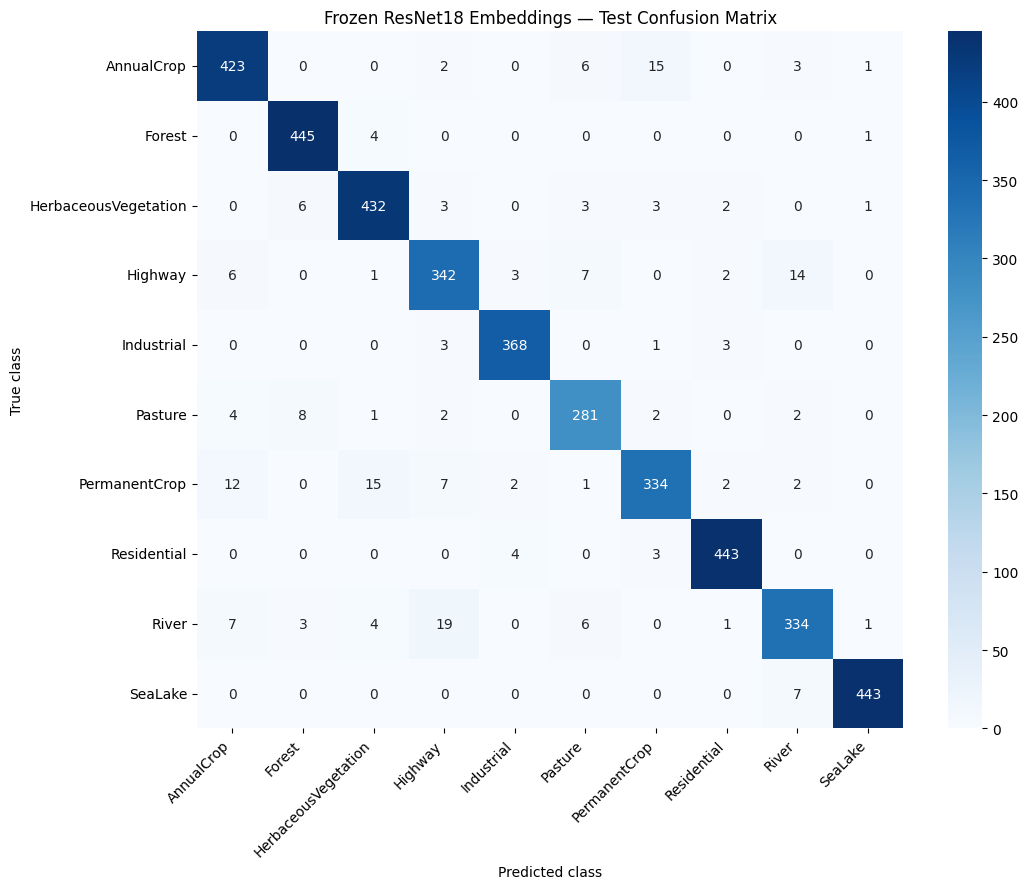

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=class_indices,
)

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)

ax.set_title("Frozen ResNet18 Embeddings — Test Confusion Matrix")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

fig.savefig(
    RESULTS_DIR / "test_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [20]:
import json
import joblib

prediction_table = pd.DataFrame({
    "dataset_index": idx_test,
    "true_class_index": y_test,
    "true_class_name": [class_names[i] for i in y_test],
    "predicted_class_index": test_predictions,
    "predicted_class_name": [
        class_names[i] for i in test_predictions
    ],
    "confidence": test_probabilities.max(axis=1),
})

for column, class_name in enumerate(class_names):
    prediction_table[f"probability_{class_name}"] = (
        test_probabilities[:, column]
    )

prediction_table.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False,
)

joblib.dump(
    final_model,
    RESULTS_DIR / "frozen_resnet18_logistic_regression.joblib",
)

metric_names = [
    "accuracy",
    "macro_f1",
    "log_loss",
    "multiclass_brier_score",
    "expected_calibration_error",
]
selected_validation_metrics = {
    name: float(ranked_results.loc[0, name])
    for name in metric_names
}

experiment_summary = {
    "representation": "ImageNet-pretrained frozen ResNet18",
    "embedding_dimension": 512,
    "pretrained_weights": weights.name,
    "preprocessing": repr(preprocess),
    "classifier": "standardized multinomial logistic regression",
    "selected_C": SELECTED_C,
    "selection_rule": (
        "Highest validation macro-F1, then lower log loss, "
        "then smaller C"
    ),
    "split_seed": 42,
    "split_checksum": "f97c4ec9a27435a932662d5a8b707255",
    "training_samples": len(y_train),
    "validation_samples": len(y_val),
    "final_fit_samples": len(y_train_validation),
    "test_samples": len(y_test),
    "validation_metrics": selected_validation_metrics,
    "test_evaluated_once": True,
    "test_metrics": {
        name: float(value)
        for name, value in test_metrics.items()
    },
    "environment": {
        "python": platform.python_version(),
        "pytorch": torch.__version__,
        "torchvision": torchvision.__version__,
        "scikit_learn": sklearn.__version__,
        "cuda": torch.version.cuda,
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),
    },
    "limitations": [
        "The image-level split does not measure geographic generalization.",
        "The test set was evaluated once after model selection.",
        "The CNN was frozen and was not fine-tuned on EuroSAT.",
    ],
}

with open(
    RESULTS_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(experiment_summary, file, indent=2)

print("Artifacts saved to:", RESULTS_DIR)

Artifacts saved to: /kaggle/working/frozen_resnet18


## 11. Saved artifacts and baseline comparison

In [21]:
handcrafted_baseline = {
    "accuracy": 0.7476543209876543,
    "macro_f1": 0.7346142817553842,
    "log_loss": 0.7374149953338679,
    "multiclass_brier_score": 0.3603268434120657,
    "expected_calibration_error": 0.024566124934231395,
}

comparison = pd.DataFrame({
    "handcrafted_features": handcrafted_baseline,
    "frozen_resnet18": test_metrics,
})

comparison["difference_resnet_minus_handcrafted"] = (
    comparison["frozen_resnet18"]
    - comparison["handcrafted_features"]
)

display(comparison)

comparison.to_csv(
    RESULTS_DIR / "model_comparison.csv"
)

,handcrafted_features,frozen_resnet18,difference_resnet_minus_handcrafted
accuracy,0.747654,0.949383,0.201728
macro_f1,0.734614,0.947055,0.212441
log_loss,0.737415,0.159799,-0.577616
multiclass_brier_score,0.360327,0.078636,-0.281691
expected_calibration_error,0.024566,0.020928,-0.003638


## Findings and limitations

- The selected frozen-CNN classifier reached test accuracy **0.9494** and
  macro-F1 **0.9471**, improving on the handcrafted baseline by approximately
  20.2 and 21.2 percentage points respectively.
- Test log loss fell from **0.7374** to **0.1598**, and the multiclass Brier
  score fell from **0.3603** to **0.0786**. Top-label ECE changed only modestly,
  from **0.0246** to **0.0209**; calibration should therefore remain a separate
  analysis rather than be inferred from accuracy alone.
- PermanentCrop, River, and Highway remain the weakest classes by F1, while
  SeaLake, Residential, and Industrial are strongest.
- Validation ECE is descriptive because the same validation partition selected
  the classifier. A later calibration stage must define a separate calibration
  protocol before fitting temperature scaling.
- The fixed split is image-level and does not establish generalization to unseen
  geographic regions. Nearby or visually related Sentinel-2 patches may occur
  across partitions.
- This experiment evaluates a frozen ImageNet representation. It does not yet
  measure the effect of end-to-end EuroSAT fine-tuning.